# 05 - k sample per cluster

Simple notebook for drawing a sample with exactly `k_per_cluster` units from each FIP-balanced cluster, using the `graphical_sampling` package.

The package does the important work:

- `gs.Population` builds the population.
- `gs.clustering.FIPBalancedNMeans` builds clusters with `r_sample_per_cluster=k_per_cluster`.
- `fbn.fit_zones(...)` adds zones inside each cluster.
- `gs.Order.from_clusters(...)` builds the ordered design structure.
- `gs.Design.from_order(...).sample(1)` draws the k-per-cluster sample.

The only non-package sampling below is the SRS comparison, which is one line with `np.random.choice`.

## 1. Working Directory

This cell moves the notebook to the `simulations` folder, so relative paths like `populations/real/...` work.

In [285]:
from pathlib import Path
import os

def set_working_directory(prefer='simulations'):
    cwd = Path.cwd().resolve()
    candidates = []

    if cwd.name == 'jupyters' and cwd.parent.name == prefer:
        candidates.append(cwd.parent)

    for path in [cwd, *cwd.parents]:
        if path.name == prefer:
            candidates.append(path)
            break

    candidates.extend([
        cwd / prefer,
        cwd.parent / prefer,
        Path.home() / 'projects' / 'graphical-sampling' / prefer,
    ])

    for path in candidates:
        if path.exists() and (path / 'populations').exists():
            os.chdir(path)
            print(f'Working directory: {Path.cwd()}')
            return Path.cwd()

    print(f'Working directory unchanged: {Path.cwd()}')
    return Path.cwd()

WORKDIR = set_working_directory()

%load_ext autoreload
%autoreload 2


Working directory: /home/bardia/projects/graphical-sampling/simulations
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Imports

Use your package as `gs`. The rest is only for reading data, SRS, and plotting.

In [286]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import graphical_sampling as gs

plt.rcParams['figure.dpi'] = 130


## 3. Parameters

Change this cell when you want another population or another `k`.

In [287]:
population_file = Path('populations/real/RegularPop1000.csv')
x_col = 'x'
y_col = 'y'

k_per_cluster = 4
num_clusters = 4
n = k_per_cluster * num_clusters

centroid_grid_x = 5
init_clust_method = 'expanded'
split_size = 0.001

# Zones are used by the package design below.
num_zones_per_cluster = k_per_cluster
zone_mode = 'cluster'
zone_strategy = 'lexico_yx'
point_strategy = 'lexico_yx'

# Set to an integer for reproducible SRS. Leave None for a fresh SRS each run.
srs_seed = None


## 4. Load Population

This creates the `gs.Population`. Here we use equal inclusion probabilities.

In [288]:
df = pd.read_csv(population_file)
coords = df[[x_col, y_col]].to_numpy(dtype=float)

pop = gs.Population(
    coords=coords,
    inclusions=np.ones(len(df)),
    variable=np.zeros(len(df)),
    n=n,
)

print(f'Population: {population_file.name}')
print(f'N = {pop.N}')
print(f'n = {pop.n}')


Population: RegularPop1000.csv
N = 1000
n = 16


## 5. Build Package Design

This is the main cell. It uses your package to build clusters, zones, order, and design.

In [289]:
fbn = gs.clustering.FIPBalancedNMeans(
    n=n,
    r_sample_per_cluster=k_per_cluster,
    centroid_grid_x=centroid_grid_x,
    init_clust_method=init_clust_method,
    split_size=split_size,
)

fbn.fit(pop)

fbn.fit_zones(
    num_zones=num_zones_per_cluster,
    mode=zone_mode,
)

order = gs.Order.from_clusters(
    pop,
    fbn.clusters,
    zone_strategy=zone_strategy,
    point_strategy=point_strategy,
)

design = gs.Design.from_order(pop, order)

cluster_masses = fbn.membership.T @ pop.inclusions
zone_counts = [len(cluster.zones) for cluster in fbn.clusters]

print(f'clusters = {len(fbn.clusters)}')
print(f'zones per cluster = {zone_counts}')
print(f'cluster mass = {cluster_masses.round(6).tolist()}')


clusters = 4
zones per cluster = [4, 4, 4, 4]
cluster mass = [4.0, 4.0, 4.0, 4.0]


## 6. Draw Samples

`k_sample` comes from your package design. `srs_sample` is a simple random sample with the same total `n`.

In [290]:
k_sample = design.sample(1)[0]

rng = np.random.default_rng(srs_seed)
srs_sample = rng.choice(pop.N, size=n, replace=False)

print(f'k sample size = {len(k_sample)}')
print(f'SRS sample size = {len(srs_sample)}')


k sample size = 16
SRS sample size = 16


## 7. Check Counts

The package sample should have exactly `k_per_cluster` units from each cluster. SRS can be uneven.

In [291]:
cluster_ids = range(len(fbn.clusters))

k_counts = (
    pd.Series(fbn.labels[k_sample])
    .value_counts()
    .sort_index()
    .reindex(cluster_ids, fill_value=0)
)

srs_counts = (
    pd.Series(fbn.labels[srs_sample])
    .value_counts()
    .sort_index()
    .reindex(cluster_ids, fill_value=0)
)

count_table = pd.DataFrame({
    'k_sample': k_counts,
    'srs': srs_counts,
})

display(count_table)

assert len(k_sample) == n
assert len(np.unique(k_sample)) == n
assert (k_counts == k_per_cluster).all()
assert len(srs_sample) == n
assert len(np.unique(srs_sample)) == n


,k_sample,srs
0,4,3
1,4,2
2,4,4
3,4,7


## 8. Plots

Population, package clusters/zones, k-per-cluster sample, and SRS sample.

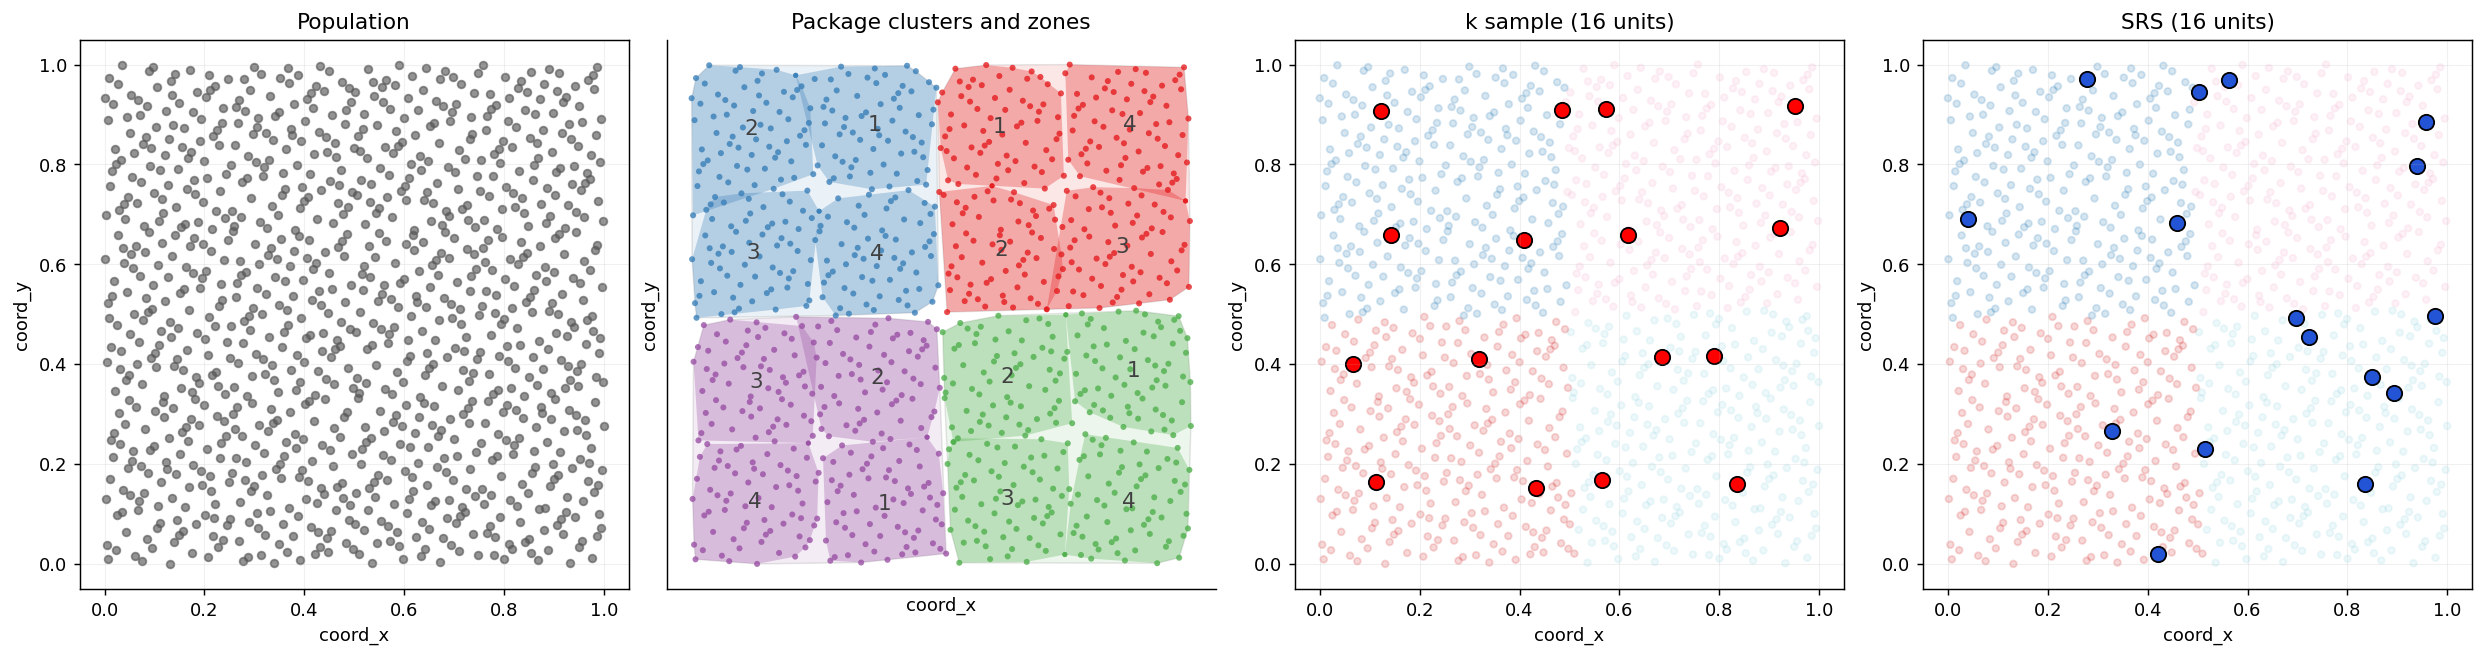

In [292]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.8), constrained_layout=True)

axes[0].scatter(pop.coords[:, 0], pop.coords[:, 1], s=18, color='0.35', alpha=0.65)
axes[0].set_title('Population')

fbn.plot(mode='soft', ax=axes[1], show_zone_labels=True)
axes[1].set_title('Package clusters and zones')

axes[2].scatter(pop.coords[:, 0], pop.coords[:, 1], c=fbn.labels, cmap='tab20', s=14, alpha=0.18)
axes[2].scatter(pop.coords[k_sample, 0], pop.coords[k_sample, 1], s=72, color='red', edgecolor='black')
axes[2].set_title(f'k sample ({len(k_sample)} units)')

axes[3].scatter(pop.coords[:, 0], pop.coords[:, 1], c=fbn.labels, cmap='tab20', s=14, alpha=0.18)
axes[3].scatter(pop.coords[srs_sample, 0], pop.coords[srs_sample, 1], s=72, color='#2454D6', edgecolor='black')
axes[3].set_title(f'SRS ({len(srs_sample)} units)')

for ax in axes:
    ax.set_xlabel('coord_x')
    ax.set_ylabel('coord_y')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(alpha=0.18, linewidth=0.6)

plt.show()


## 9. Sample Data

Small tables for checking which units were selected.

In [293]:
k_sample_df = df.iloc[k_sample].copy()
k_sample_df['sample_index'] = k_sample
k_sample_df['cluster'] = fbn.labels[k_sample]

srs_sample_df = df.iloc[srs_sample].copy()
srs_sample_df['sample_index'] = srs_sample
srs_sample_df['cluster'] = fbn.labels[srs_sample]

display(
    k_sample_df
    .sort_values("cluster")
    .head(20)
)
display(
    srs_sample_df
    .sort_values("cluster")
    .head(20)
)

,x,y,sample_index,cluster
278,0.40820,0.64929,278,0
504,0.12305,0.90626,504,0
548,0.14160,0.65935,548,0
990,0.48340,0.90901,990,0
886,0.43262,0.15181,886,1
776,0.06543,0.40146,776,1
650,0.31738,0.40969,650,1
184,0.11328,0.16369,184,1
585,0.57129,0.91038,585,2
953,0.61621,0.65798,953,2


,x,y,sample_index,cluster
738,0.278320,0.969360,738,0
336,0.041016,0.690440,336,0
174,0.457030,0.682210,174,0
970,0.327150,0.267030,970,1
982,0.420900,0.020119,982,1
303,0.955080,0.883860,303,2
15,0.937500,0.796070,15,2
513,0.500980,0.943300,513,2
9,0.562500,0.968910,9,2
961,0.514650,0.230000,961,3
